In [116]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

# 한글 폰트 자동 설정(환경에 따라 없으면 무시)
for _font in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    try:
        plt.rcParams["font.family"] = _font
        break
    except Exception:
        continue
plt.rcParams["axes.unicode_minus"] = False


def find_browser_automation_root(start: Path | None = None) -> Path:
    base = (start or Path.cwd()).resolve()
    for current in [base, *base.parents]:
        if current.name == "browser_automation" and (current / "collector_api").exists():
            return current
    raise FileNotFoundError("browser_automation 루트를 찾지 못했습니다.")


ROOT = find_browser_automation_root()
TRIAL_DIR = ROOT / "collector_api" / "data" / "trials"
FEATURE_MD = ROOT / "analysis" / "feature.md"
print("ROOT:", ROOT)
print("TRIAL_DIR:", TRIAL_DIR)


ROOT: C:\Users\SSAFY\Desktop\ws\01_main\S14P31A203\services\ai\macro\browser_automation
TRIAL_DIR: C:\Users\SSAFY\Desktop\ws\01_main\S14P31A203\services\ai\macro\browser_automation\collector_api\data\trials


In [117]:
# feature.md 기반 3그룹

CLICK_FEATURES = [
    "time_to_first_click_ms",
    "time_from_element_visible_to_click_ms",
    "time_from_element_clickable_to_click_ms",
    "inter_click_interval_ms",
    "click_sequence_consistency_score",
    "click_position_repeat_rate",
    "click_offset_from_element_center_px",
    "click_offset_variance_px",
    "double_click_rate",
    "misclick_rate",
    "reclick_rate",
    "pre_click_mousemove_count",
    "pre_click_hover_time_ms",
    "pre_click_scroll_flag",
    "immediate_post_render_click_rate",
]

MOUSE_FEATURES = [
    "mouse_total_travel_distance_px",
    "mouse_avg_speed_px_per_ms",
    "mouse_max_speed_px_per_ms",
    "mouse_speed_change_mean",
    "mouse_acceleration_mean",
    "mouse_jerk_mean",
    "mouse_path_straightness_score",
    "mouse_path_curvature_mean",
    "mouse_direction_change_count",
    "mouse_overshoot_flag",
    "mouse_hover_dwell_time_ms",
    "mouse_stop_segment_count",
    "mousemove_event_rate",
    "inter_element_move_interval_std_ms",
    "edge_or_fixed_point_visit_rate",
    # 문자열 요약값에서 파생한 numeric
    "pre_click_path_300ms_total_distance_px",
    "pre_click_path_300ms_straightness",
    "pre_click_path_500ms_total_distance_px",
    "pre_click_path_500ms_straightness",
]

KEYBOARD_FEATURES = [
    "time_to_first_keydown_ms",
    "inter_key_interval_ms_mean",
    "inter_key_interval_ms_std",
    "keydown_to_keyup_ms_mean",
    "typing_total_duration_ms",
    "typing_speed_cps",
    "backspace_rate",
    "correction_count",
    "paste_flag",
    "focus_to_submit_ms",
]

FEATURE_GROUPS = {
    "click": CLICK_FEATURES,
    "mouse": MOUSE_FEATURES,
    "keyboard": KEYBOARD_FEATURES,
}

ALL_FEATURES = [f for group in FEATURE_GROUPS.values() for f in group]
print("all feature count:", len(ALL_FEATURES))


all feature count: 44


In [118]:
def load_feature_name_map_ko(path: Path) -> dict[str, str]:
    """feature.md의 표에서 (feature -> 한글명) 매핑을 읽어옵니다."""
    if not path.exists():
        return {}

    mapping: dict[str, str] = {}
    for raw in path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line.startswith("|"):
            continue
        parts = [p.strip() for p in line.strip("|").split("|")]
        if len(parts) < 2:
            continue
        feature = parts[0]
        if not (feature.startswith("`") and feature.endswith("`")):
            continue
        feature_key = feature.strip("`")
        feature_ko = parts[1]
        if feature_key and feature_ko:
            mapping[feature_key] = feature_ko
    return mapping


FEATURE_NAME_KO = load_feature_name_map_ko(FEATURE_MD)
print("loaded feature ko names:", len(FEATURE_NAME_KO))


loaded feature ko names: 51


In [119]:
def extract_label(payload: dict) -> str | None:
    label = payload.get("label")
    if isinstance(label, str):
        return label
    summary = payload.get("summary")
    if isinstance(summary, dict) and isinstance(summary.get("label"), str):
        return summary.get("label")
    return None


def load_trials(trial_dir: Path) -> tuple[pd.DataFrame, dict[str, int]]:
    rows: list[dict] = []
    counters = {"total": 0, "kept": 0, "skipped_other": 0, "no_label": 0}

    for path in sorted(trial_dir.glob("trial_*.json")):
        counters["total"] += 1
        payload = json.loads(path.read_text(encoding="utf-8"))

        lb = extract_label(payload)
        if lb is None:
            counters["no_label"] += 1
            continue
        if lb not in ("human", "macro"):
            counters["skipped_other"] += 1
            continue

        counters["kept"] += 1
        trial_id = int(payload.get("trialId") or payload.get("trial_id") or 0)
        summary = payload.get("summary") or {}
        metrics = payload.get("metrics") or {}

        row = {
            "trial_id": trial_id,
            "label": lb,
            "event_count": len(payload.get("eventRows", []) or []),
            "window_count": len(payload.get("windowRows", []) or []),
        }
        if isinstance(summary, dict):
            row.update(summary)
        if isinstance(metrics, dict):
            row.update(metrics)

        rows.append(row)

    df = pd.DataFrame(rows).sort_values("trial_id").reset_index(drop=True)
    return df, counters


df, counters = load_trials(TRIAL_DIR)
print("load counters:", counters)
display(df["label"].value_counts())


load counters: {'total': 324, 'kept': 324, 'skipped_other': 0, 'no_label': 0}


label
macro    164
human    160
Name: count, dtype: int64

In [120]:
PATH_RE = re.compile(r"(?P<dist>[-+]?\d+(\.\d+)?)px\s*\|\s*straight\s*(?P<straight>[-+]?\d+(\.\d+)?)", re.I)


def add_pre_click_path_features(df: pd.DataFrame) -> None:
    """raw 문자열 요약값(pre_click_mouse_path_pattern_*)을 분석용 숫자 feature로 파싱."""
    for win in [300, 500]:
        col = f"pre_click_mouse_path_pattern_{win}ms"
        if col not in df.columns:
            continue
        extracted = df[col].astype("string").str.extract(PATH_RE)
        df[f"pre_click_path_{win}ms_total_distance_px"] = pd.to_numeric(extracted["dist"], errors="coerce")
        df[f"pre_click_path_{win}ms_straightness"] = pd.to_numeric(extracted["straight"], errors="coerce")


add_pre_click_path_features(df)

for win in [300, 500]:
    a = f"pre_click_path_{win}ms_total_distance_px"
    b = f"pre_click_path_{win}ms_straightness"
    if a in df.columns:
        print(win, "ms:", a, "non-null=", int(df[a].notna().sum()), "/", len(df))
    if b in df.columns:
        print(win, "ms:", b, "non-null=", int(df[b].notna().sum()), "/", len(df))


300 ms: pre_click_path_300ms_total_distance_px non-null= 280 / 324
300 ms: pre_click_path_300ms_straightness non-null= 280 / 324
500 ms: pre_click_path_500ms_total_distance_px non-null= 320 / 324
500 ms: pre_click_path_500ms_straightness non-null= 320 / 324


In [121]:
def coerce_numeric(df: pd.DataFrame, features: list[str]) -> tuple[pd.DataFrame, list[str], list[str], list[str]]:
    existing = [f for f in features if f in df.columns]
    not_found = [f for f in features if f not in df.columns]
    frame = df[existing].apply(pd.to_numeric, errors="coerce")
    usable = [c for c in frame.columns if frame[c].notna().any()]
    dropped_all_nan = [c for c in existing if c not in usable]
    return frame[usable], usable, not_found, dropped_all_nan


def feature_stats(frame: pd.DataFrame) -> pd.DataFrame:
    n_rows = max(1, int(frame.shape[0]))
    rows = []
    for col in frame.columns:
        s = frame[col]
        non_null = s.dropna()
        rows.append(
            {
                # "feature": col,
                "feature_ko": FEATURE_NAME_KO.get(col, col),
                "count": int(non_null.shape[0]),
                "missing_rate": float(s.isna().mean()) if n_rows else np.nan,
                "mean": float(non_null.mean()) if non_null.shape[0] else np.nan,
                "min": float(non_null.min()) if non_null.shape[0] else np.nan,
                "max": float(non_null.max()) if non_null.shape[0] else np.nan,
                "var": float(non_null.var(ddof=1)) if non_null.shape[0] >= 2 else np.nan,
            }
        )
    return pd.DataFrame(rows)


def cohen_d(a: pd.Series, b: pd.Series) -> float:
    a = pd.to_numeric(a, errors="coerce").dropna()
    b = pd.to_numeric(b, errors="coerce").dropna()
    if a.shape[0] < 5 or b.shape[0] < 5:
        return float("nan")
    var_a = float(a.var(ddof=1)) if a.shape[0] >= 2 else 0.0
    var_b = float(b.var(ddof=1)) if b.shape[0] >= 2 else 0.0
    pooled = ((a.shape[0] - 1) * var_a + (b.shape[0] - 1) * var_b) / max(a.shape[0] + b.shape[0] - 2, 1)
    if pooled <= 0:
        return float("nan")
    return float((b.mean() - a.mean()) / np.sqrt(pooled))


# 그룹별 usable feature 정리
GROUP_FRAMES: dict[str, pd.DataFrame] = {}
GROUP_USABLE: dict[str, list[str]] = {}
for group_name, features in FEATURE_GROUPS.items():
    frame, usable, not_found, dropped = coerce_numeric(df, features)
    GROUP_FRAMES[group_name] = frame
    GROUP_USABLE[group_name] = usable
    print(group_name, "usable:", len(usable), "/", len(features), "not_found=", len(not_found), "dropped_all_nan=", len(dropped))


# 전체 usable feature (그룹 합집합)
usable_features = [f for g in ["click", "mouse", "keyboard"] for f in GROUP_USABLE.get(g, [])]
print("total usable features:", len(usable_features))

# 그룹별 요약(라벨별 mean 차이 + cohen's d)
for group_name in ["click", "mouse", "keyboard"]:
    usable = GROUP_USABLE.get(group_name, [])
    if not usable:
        continue

    effect_rows = []
    for feature in usable:
        s = df[feature]
        a = s[df["label"] == "human"]
        b = s[df["label"] == "macro"]
        d = cohen_d(a, b)
        effect_rows.append(
            {
                # "feature": feature,
                "feature_ko": FEATURE_NAME_KO.get(feature, feature),
                "human_mean": float(pd.to_numeric(a, errors="coerce").mean()),
                "macro_mean": float(pd.to_numeric(b, errors="coerce").mean()),
                "delta(macro-human)": float(pd.to_numeric(b, errors="coerce").mean() - pd.to_numeric(a, errors="coerce").mean()),
                "cohen_d": d,
            }
        )

    effect_df = pd.DataFrame(effect_rows).sort_values("cohen_d", ascending=False).reset_index(drop=True)
    display(effect_df)


click usable: 15 / 15 not_found= 0 dropped_all_nan= 0
mouse usable: 19 / 19 not_found= 0 dropped_all_nan= 0
keyboard usable: 10 / 10 not_found= 0 dropped_all_nan= 0
total usable features: 44


,feature_ko,human_mean,macro_mean,delta(macro-human),cohen_d
0,즉시 클릭 비율,0.076803,0.357317,0.280514,1.405447
1,더블클릭 비율,0.233800,0.430488,0.196688,0.902589
2,순서 일관성,0.951704,1.000000,0.048296,0.752682
3,클릭 전 스크롤,0.000781,0.000000,-0.000781,-0.112504
4,첫 클릭 시간,1621.915000,1583.538415,-38.376585,-0.112817
5,좌표 반복률,0.002865,0.000000,-0.002865,-0.194469
6,재클릭 비율,0.004936,0.000000,-0.004936,-0.243607
7,오차 분산,12729.069166,0.022615,-12729.046551,-0.445527
8,클릭 전 hover,253.144239,172.740976,-80.403263,-0.732179
9,오클릭 비율,0.060789,0.000000,-0.060789,-0.922651


,feature_ko,human_mean,macro_mean,delta(macro-human),cohen_d
0,300ms 이동거리,68.915753,742.831343,673.915590,3.541219
1,500ms 이동거리,449.370513,932.501829,483.131316,1.734161
2,속도 변화,0.389055,3.949214,3.560159,1.235704
3,경로 직선성,0.384146,0.453877,0.069731,1.026235
4,평균 속도,0.385598,0.477972,0.092373,0.816061
5,경로 곡률,0.197835,0.316241,0.118406,0.758636
6,최대 속도,10.422780,18.688735,8.265954,0.601648
7,가속도 변화,0.047589,0.247701,0.200112,0.420913
8,평균 dwell,208.506366,234.549692,26.043325,0.362886
9,저크 평균,0.006559,0.080102,0.073543,0.175632


,feature_ko,human_mean,macro_mean,delta(macro-human),cohen_d
0,초당 입력 수,7.385540,12.960541,5.575001,0.787023
1,키 누름 시간,129.399510,112.578136,-16.821375,-0.354933
2,수정 횟수,0.787500,0.000000,-0.787500,-0.554794
3,총 입력 시간,1382.857500,754.500610,-628.356890,-0.632697
4,백스페이스 비율,0.052586,0.000000,-0.052586,-0.712456
5,첫 키 입력 시간,489.486250,112.185366,-377.300884,-0.775907
6,키 간격 평균,187.107062,125.750102,-61.356960,-0.805056
7,키 간격 표준편차,136.777219,42.875591,-93.901628,-0.917318
8,포커스 후 확인,2693.134375,1339.606098,-1353.528277,-1.327828
9,붙여넣기 여부,0.000000,0.000000,0.000000,NaN


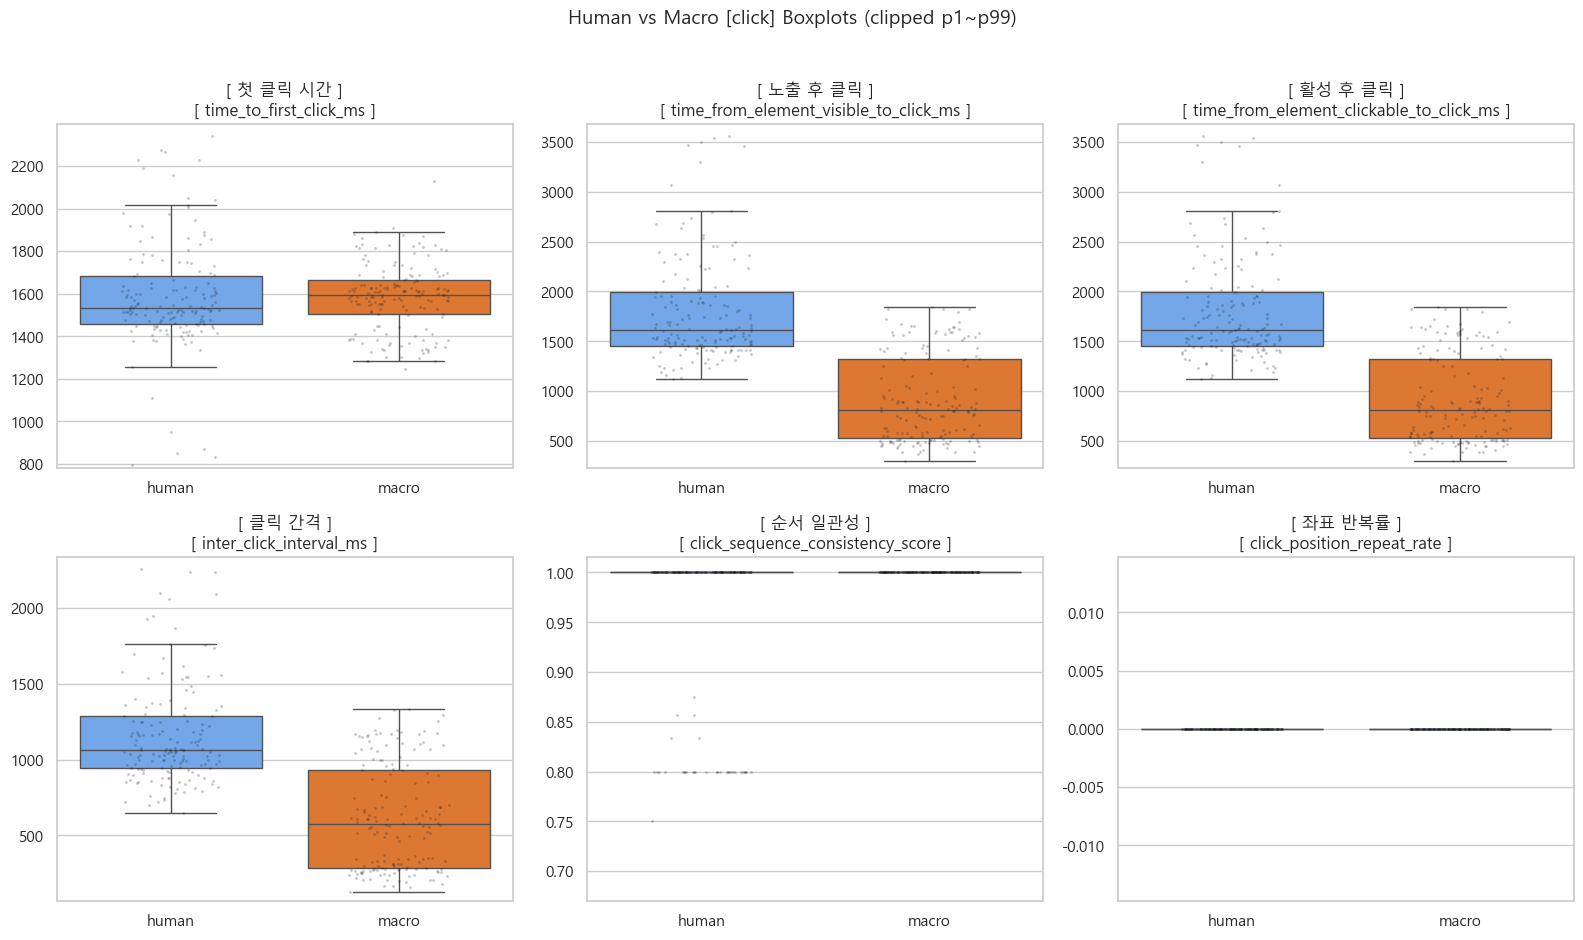

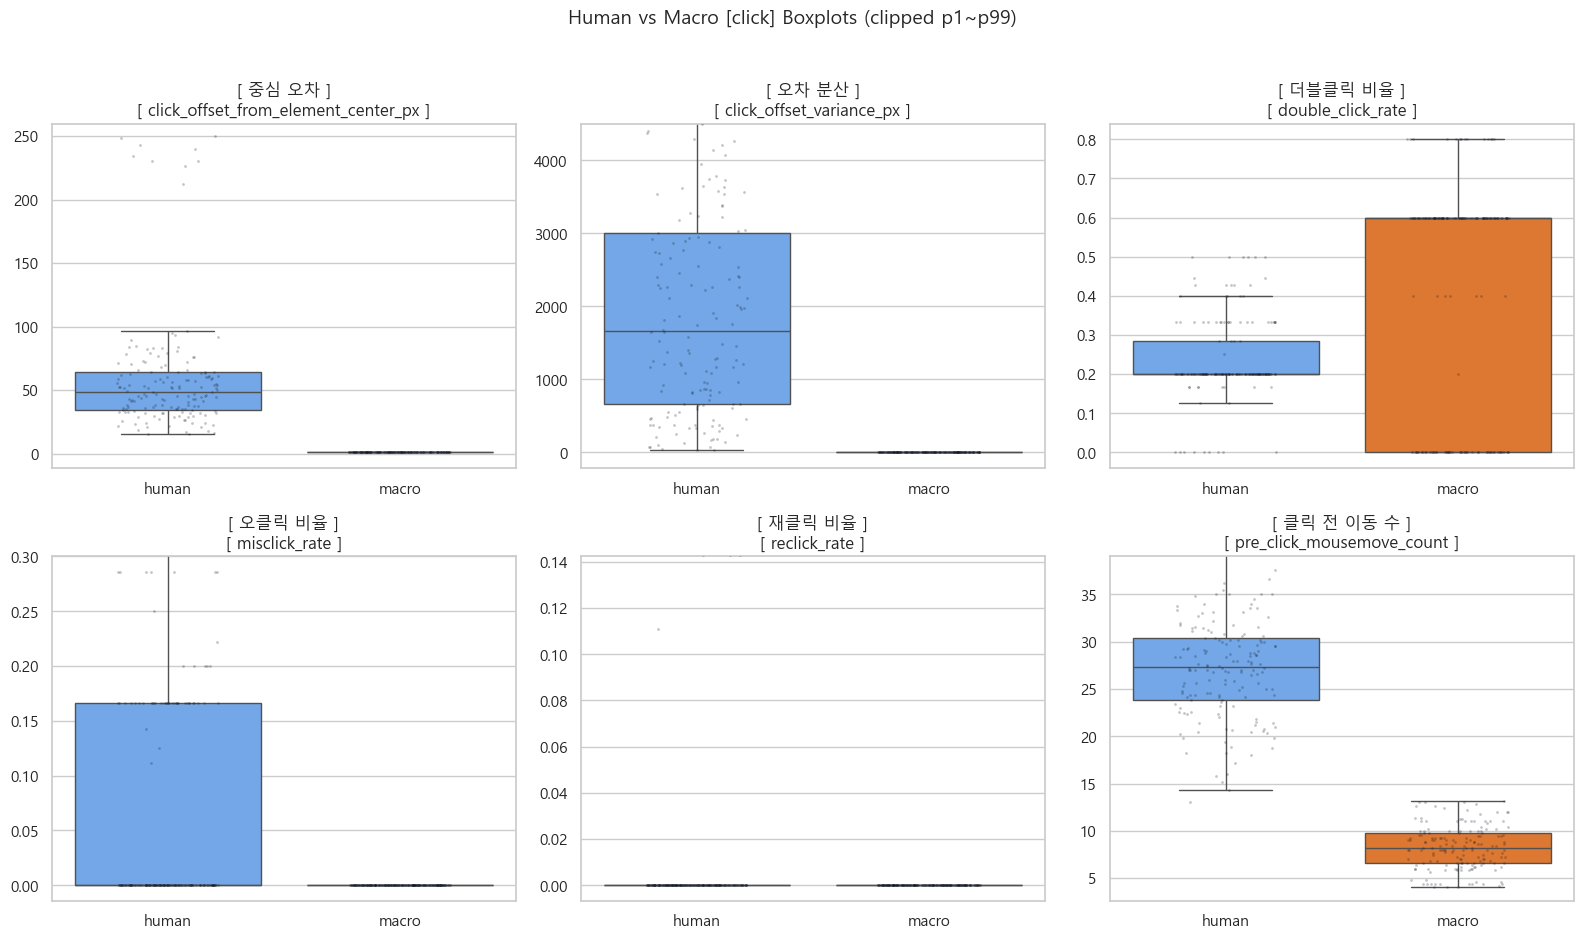

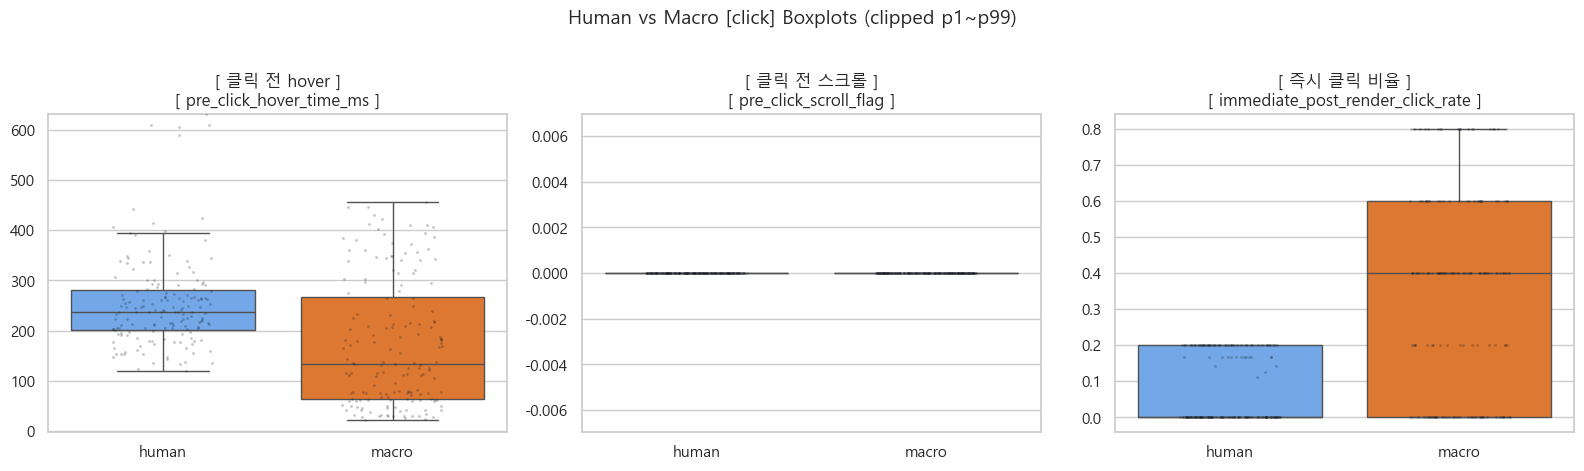

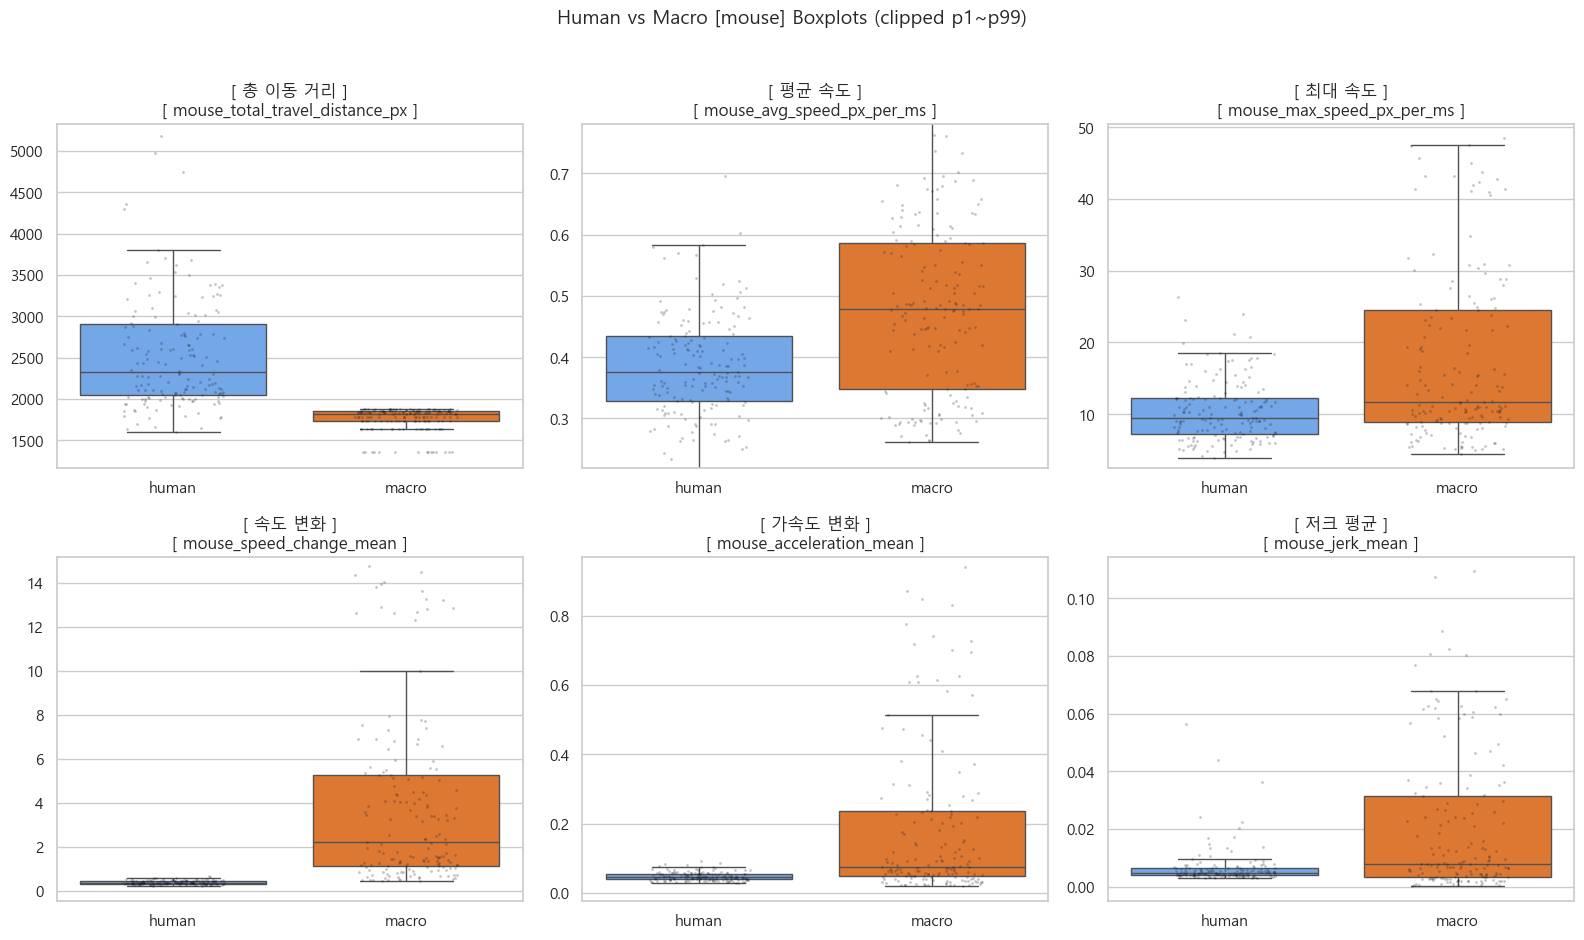

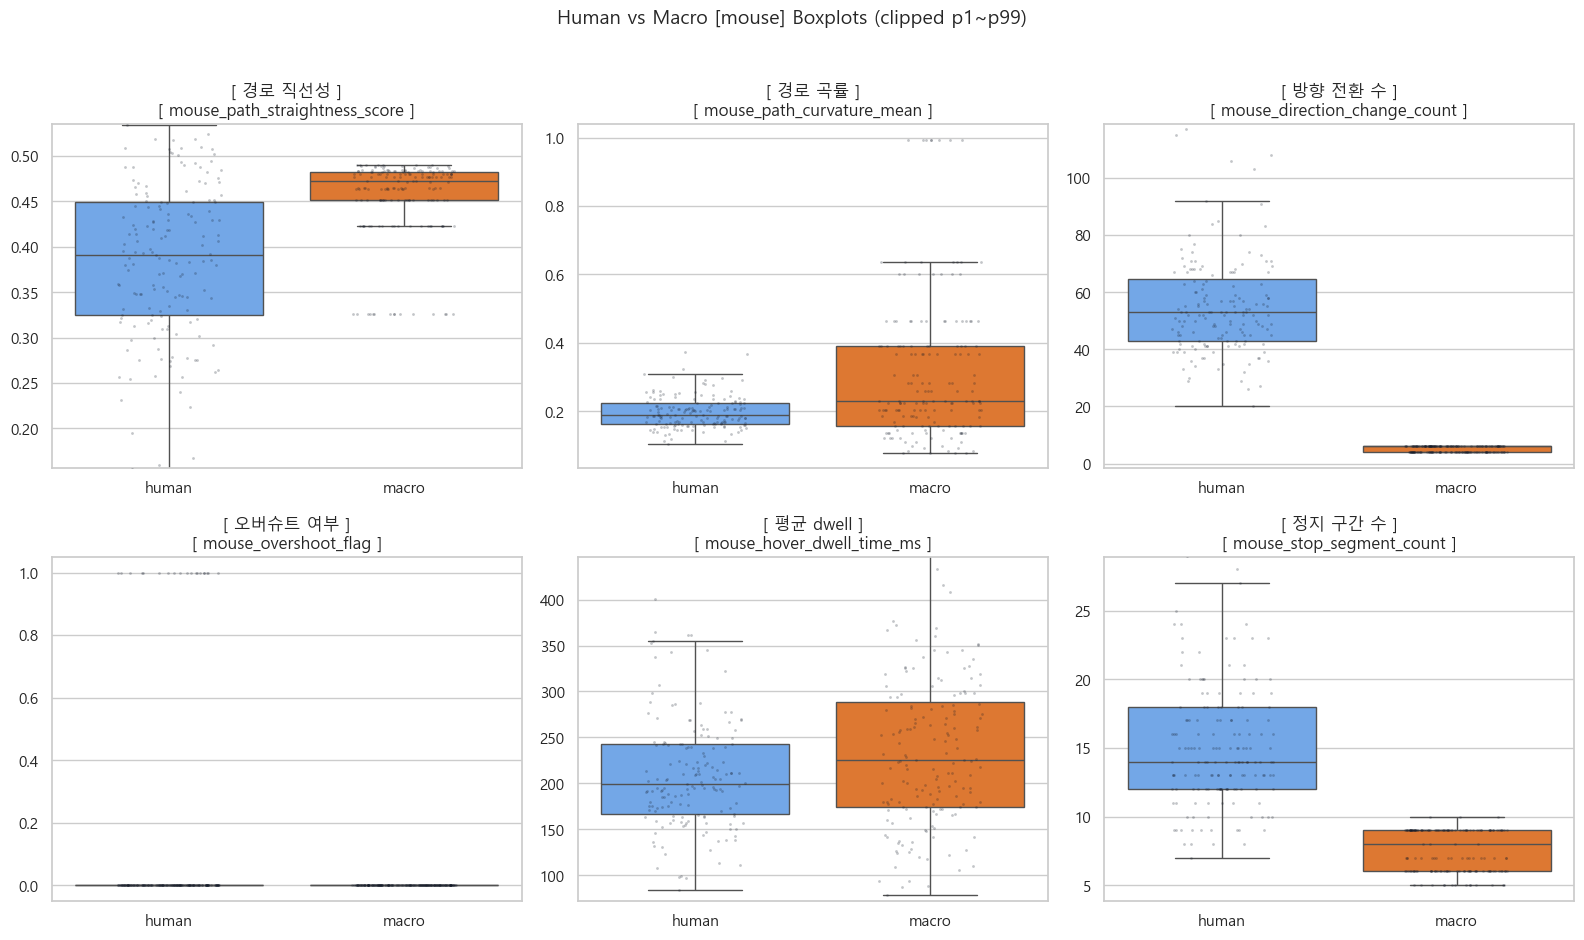

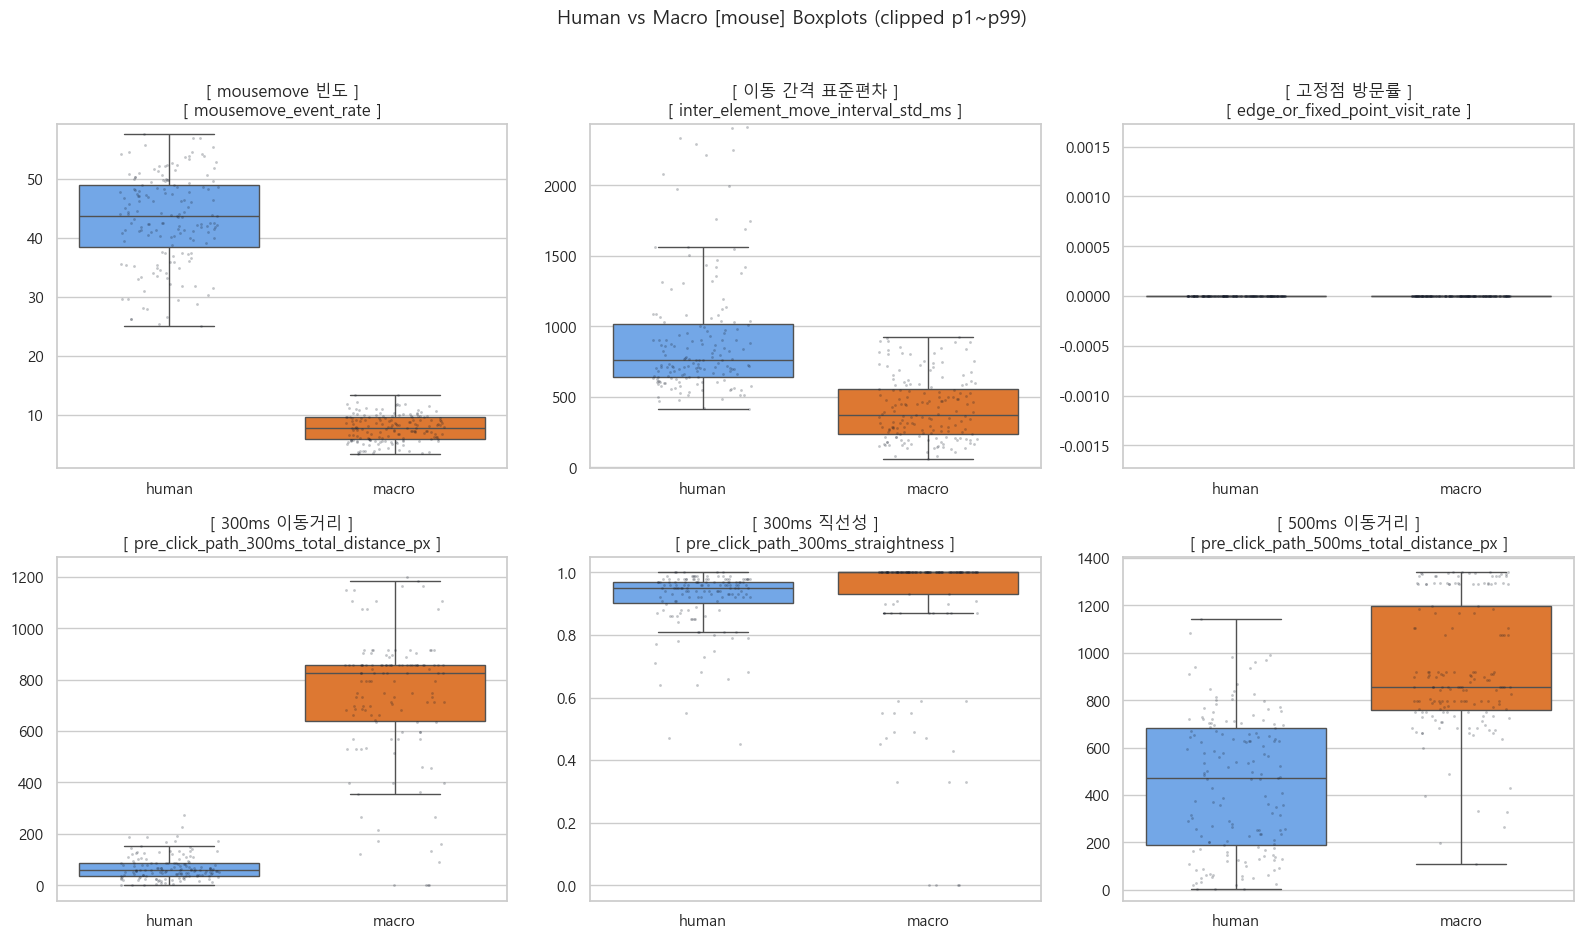

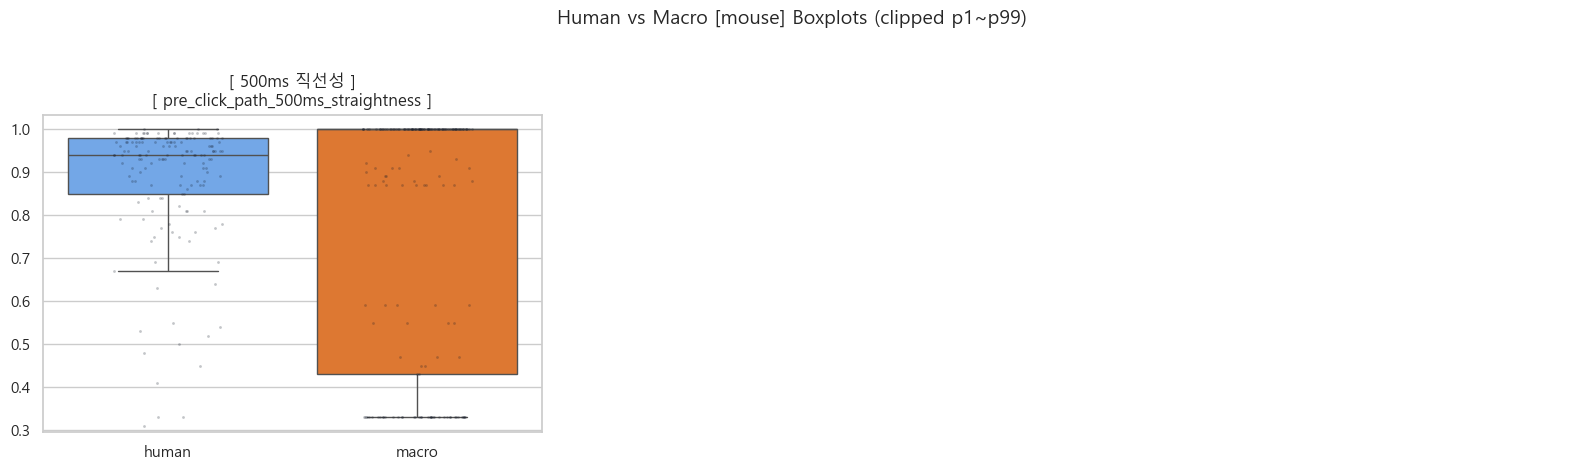

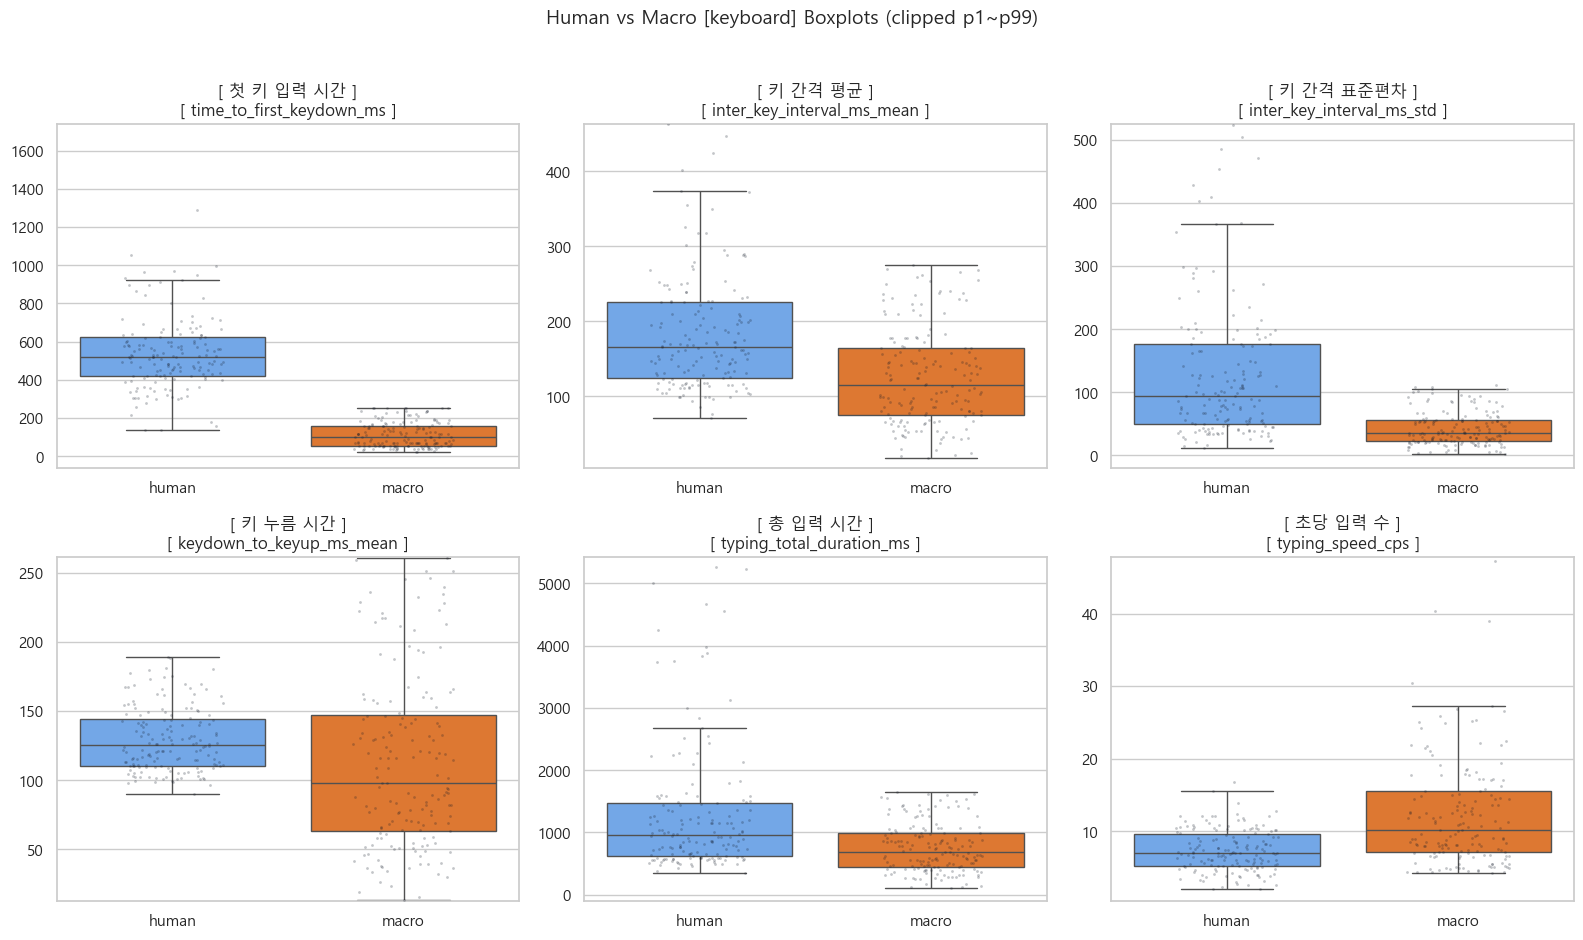

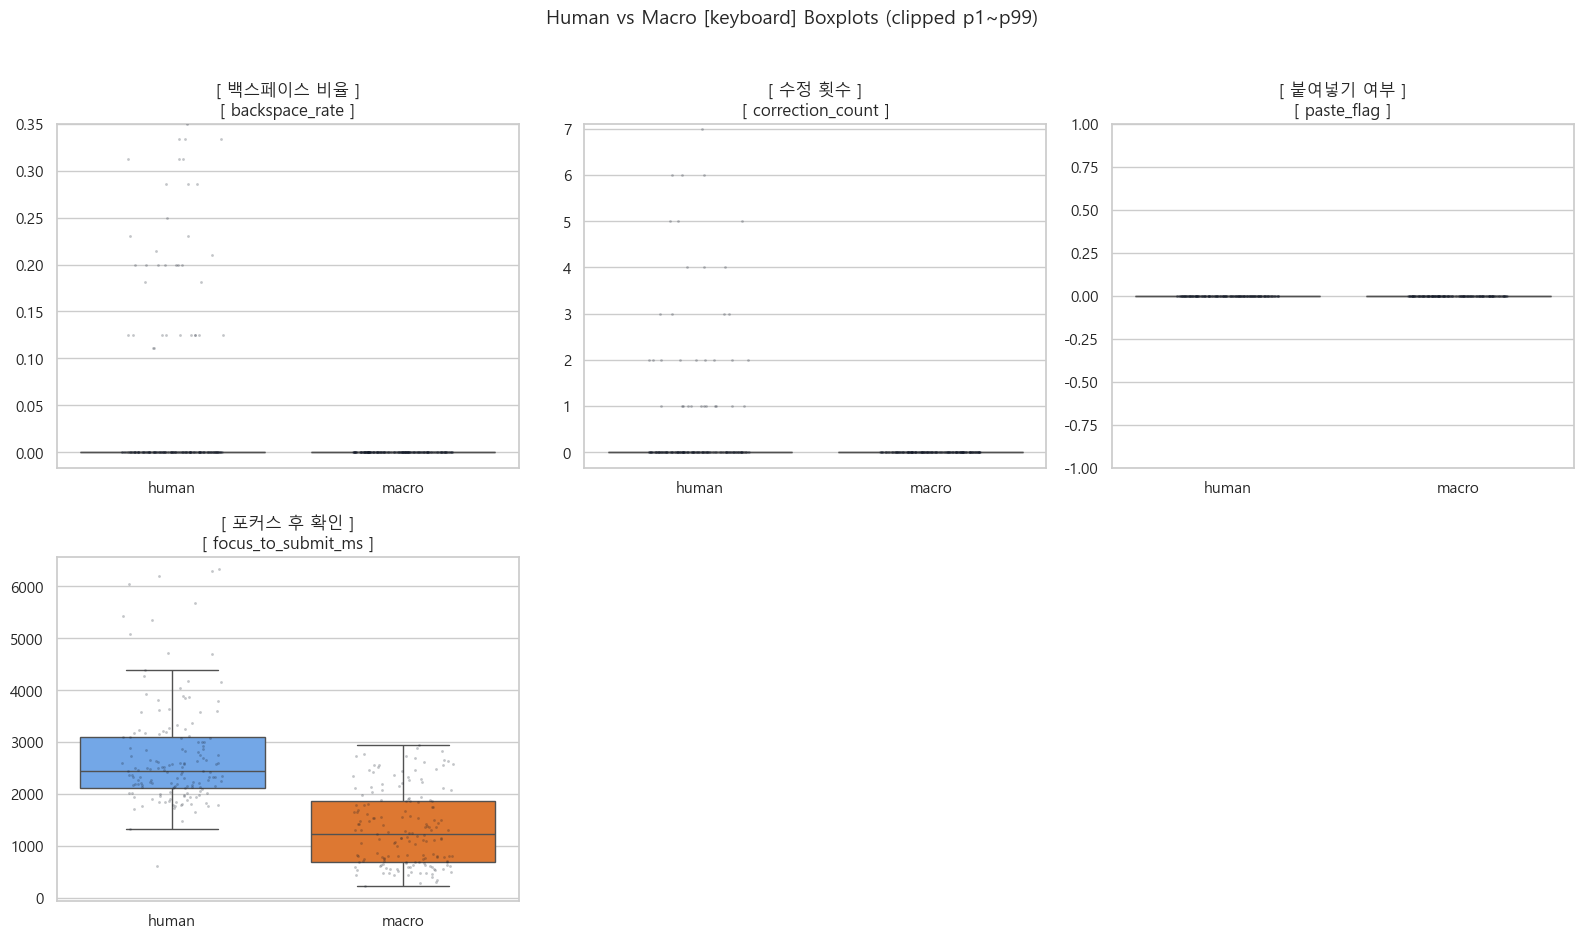

In [122]:
# 비교 박스플롯(가독성 우선): p1~p99 클리핑 + 자동 타이트닝
CLIP_Q_LOW = 0.01
CLIP_Q_HIGH = 0.99
SUBPLOT_COLS = 3
FEATURES_PER_FIG = 6
MAX_STRIP_PER_LABEL = 250


def _clip_limits(values: pd.Series, q_low: float, q_high: float) -> tuple[float, float] | None:
    values = pd.to_numeric(values, errors="coerce").dropna()
    if values.empty:
        return None

    q25 = float(values.quantile(0.25))
    q75 = float(values.quantile(0.75))
    iqr = q75 - q25

    def limits_for(ql: float, qh: float) -> tuple[float, float] | None:
        lo = float(values.quantile(ql))
        hi = float(values.quantile(qh))
        if not np.isfinite(lo) or not np.isfinite(hi):
            return None
        if hi <= lo:
            med = float(values.median())
            std = float(values.std(ddof=1)) if values.shape[0] >= 2 else 0.0
            pad = std if std > 0 else (1.0 if med == 0 else abs(med) * 0.05)
            return (med - pad, med + pad)
        pad = (hi - lo) * 0.05
        return (lo - pad, hi + pad)

    base = limits_for(q_low, q_high)
    if base is None:
        return None

    lo, hi = base
    span = hi - lo
    if iqr <= 0:
        return (lo, hi)

    ratio = span / max(iqr, 1e-9)

    if ratio > 60:
        tightened = limits_for(0.05, 0.95)
        if tightened is not None:
            lo, hi = tightened
            span = hi - lo
            ratio = span / max(iqr, 1e-9)
    if ratio > 90:
        tightened = limits_for(0.1, 0.9)
        if tightened is not None:
            lo, hi = tightened

    return (lo, hi)


def plot_compare_for_group(group_name: str, features: list[str]) -> None:
    usable = GROUP_USABLE.get(group_name, [])
    if not usable:
        print("skip:", group_name)
        return

    for start in range(0, len(usable), FEATURES_PER_FIG):
        subset = usable[start : start + FEATURES_PER_FIG]
        rows = int(np.ceil(len(subset) / SUBPLOT_COLS))
        fig, axes = plt.subplots(rows, SUBPLOT_COLS, figsize=(16, 4.6 * rows))
        if not isinstance(axes, np.ndarray):
            axes = np.array([axes])
        axes = axes.reshape(rows, SUBPLOT_COLS)

        for i, feature in enumerate(subset):
            r = i // SUBPLOT_COLS
            c = i % SUBPLOT_COLS
            ax = axes[r, c]

            s = pd.to_numeric(df[feature], errors="coerce")
            plot_df = pd.DataFrame({"label": df["label"], "value": s}).dropna()
            if plot_df.empty:
                feature_ko = FEATURE_NAME_KO.get(feature, feature)
                ax.set_title(f"[ {feature_ko} ]\n[ {feature} ]")
                ax.axis("off")
                continue

            limits = _clip_limits(plot_df["value"], CLIP_Q_LOW, CLIP_Q_HIGH)

            sns.boxplot(
                data=plot_df,
                x="label",
                y="value",
                hue="label",
                order=["human", "macro"],
                hue_order=["human", "macro"],
                legend=False,
                dodge=False,
                ax=ax,
                palette={"human": "#60a5fa", "macro": "#f97316"},
                fliersize=0,
            )

            # 점(샘플)도 함께 표시: 분포/겹침 확인용
            strip_parts = []
            for lb in ["human", "macro"]:
                part = plot_df[plot_df["label"] == lb]
                if part.empty:
                    continue
                strip_parts.append(part.sample(min(len(part), MAX_STRIP_PER_LABEL), random_state=42))
            if strip_parts:
                strip_df = pd.concat(strip_parts, ignore_index=True)
                sns.stripplot(
                    data=strip_df,
                    x="label",
                    y="value",
                    ax=ax,
                    color="#111827",
                    alpha=0.25,
                    size=2,
                    jitter=0.22,
                )

            if limits is not None:
                ax.set_ylim(*limits)

            feature_ko = FEATURE_NAME_KO.get(feature, feature)
            ax.set_title(f"[ {feature_ko} ]\n[ {feature} ]")
            ax.set_xlabel("")
            ax.set_ylabel("")

        total_axes = rows * SUBPLOT_COLS
        for j in range(len(subset), total_axes):
            r = j // SUBPLOT_COLS
            c = j % SUBPLOT_COLS
            axes[r, c].axis("off")

        fig.suptitle(
            f"Human vs Macro [{group_name}] Boxplots (clipped p{int(CLIP_Q_LOW*100)}~p{int(CLIP_Q_HIGH*100)})",
            y=1.02,
            fontsize=14,
        )
        plt.tight_layout()
        plt.show()


for group_name in ["click", "mouse", "keyboard"]:
    plot_compare_for_group(group_name, FEATURE_GROUPS[group_name])


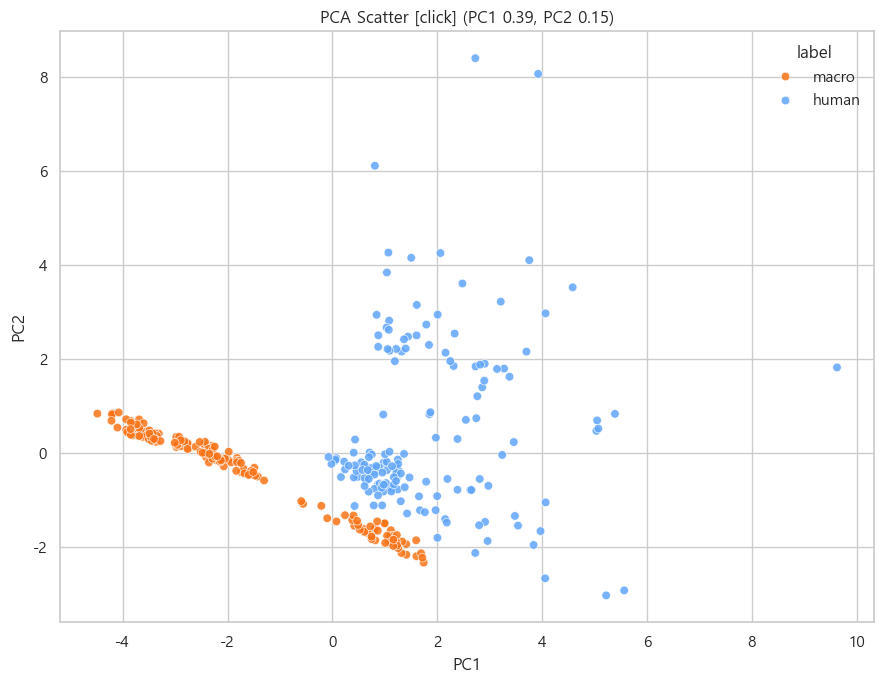

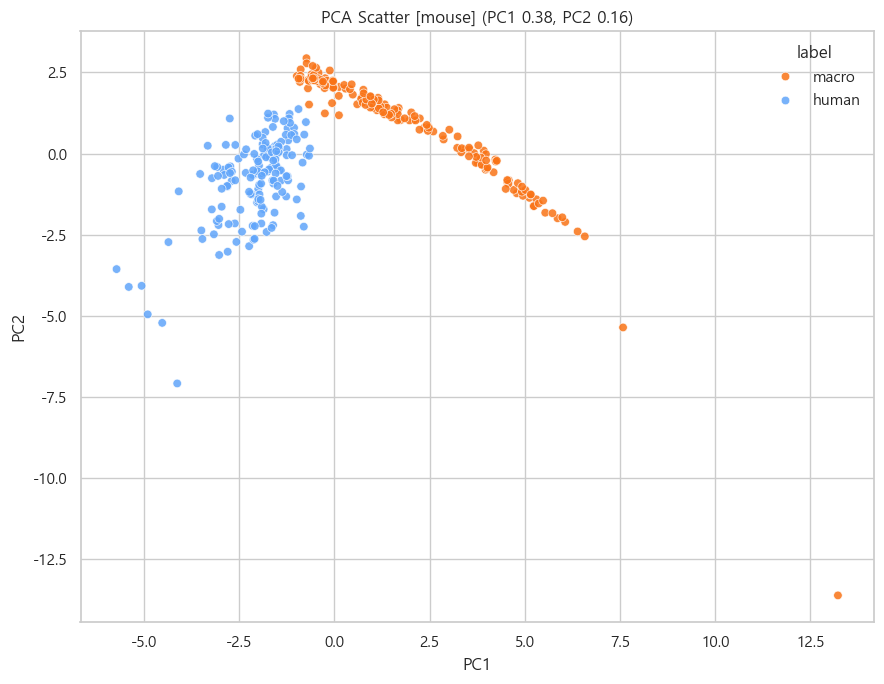

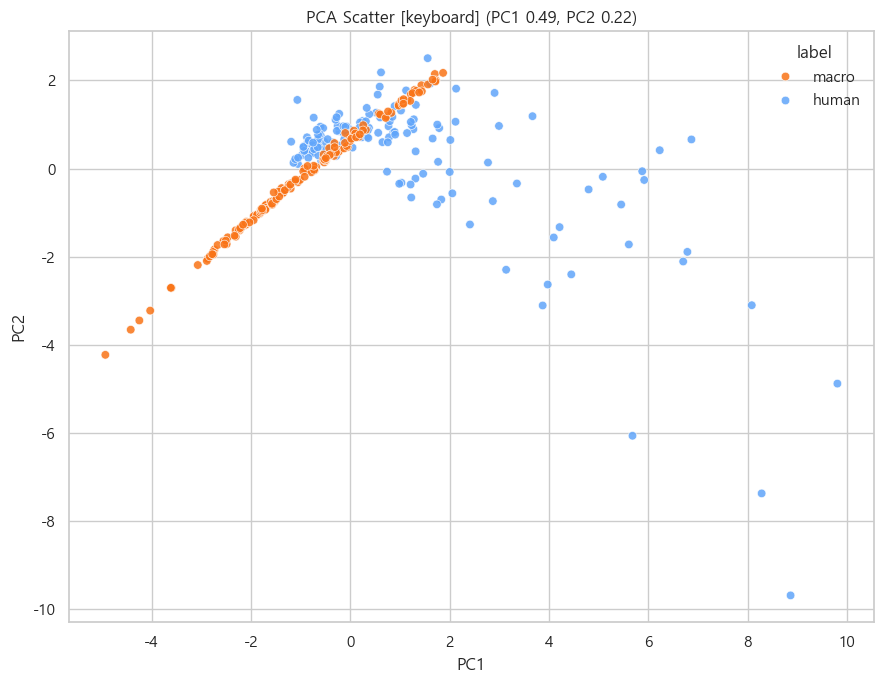

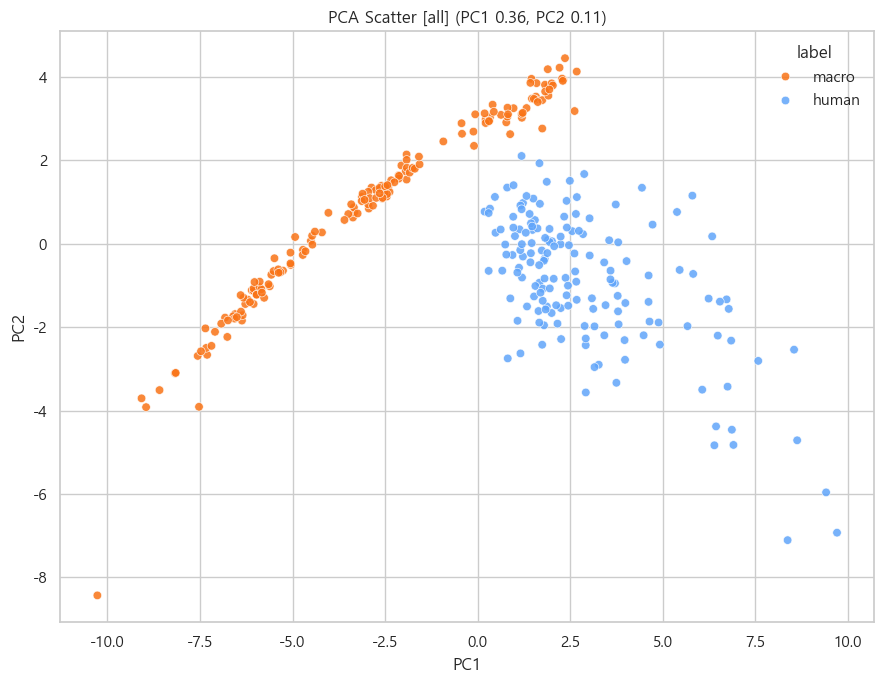

In [123]:
def plot_pca_scatter(title: str, features: list[str]) -> None:
    present = [f for f in features if f in df.columns]
    if len(present) < 2:
        print("skip PCA:", title, "(present < 2)")
        return

    X_raw_local = df[present].apply(pd.to_numeric, errors="coerce")
    usable = [c for c in X_raw_local.columns if X_raw_local[c].notna().any()]
    if len(usable) < 2:
        print("skip PCA:", title, "(usable < 2)")
        return

    pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=2, random_state=42)),
        ]
    )

    xy = pipe.fit_transform(X_raw_local[usable])
    pca = pipe.named_steps["pca"]
    explained = pca.explained_variance_ratio_ if hasattr(pca, "explained_variance_ratio_") else [float("nan"), float("nan")]

    plt.figure(figsize=(9, 7))
    sns.scatterplot(
        x=xy[:, 0],
        y=xy[:, 1],
        hue=df["label"],
        palette={"human": "#60a5fa", "macro": "#f97316"},
        s=38,
        alpha=0.85,
    )
    plt.title(f"PCA Scatter [{title}] (PC1 {explained[0]:.2f}, PC2 {explained[1]:.2f})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()


# 그룹별 PCA (click / mouse / keyboard)
for group_name, group_features in FEATURE_GROUPS.items():
    plot_pca_scatter(group_name, group_features)

# 전체 feature PCA
plot_pca_scatter("all", usable_features)
